# 00 — Analysis Summary
## NIR Spectroscopy: Hardwood vs Vinyl Flooring

**Dataset:** `2026-05-21_22-59_Method Dev_wavelength_range_1450-2450.xlsx` — 134 usable scans, 249 wavelengths (1454–2446 nm)
**Plan reference:** `ANALYSIS_PLAN.md` → Final Deliverable

This notebook consolidates the eight analyses (SVM, XGBoost, KNN, Clustering, RFE, SVR, ANOVA, Interpretability)
into one place: a master performance table, a consensus feature-importance ranking, best-model
recommendations, and the key scientific takeaways.

> All metrics below are **transcribed from the executed outputs** of notebooks `01`–`08`; this notebook
> recombines them and does not re-train any model, so it runs in seconds with no heavy dependencies.

**Class structure (n = 134):** LVP 90 (6 mil ×33, 12 mil ×30, 22 mil ×27) · Hardwood 44
(pine 11, fir 10, mahogany 6, oak 6, poplar 6, particle board 5).

**Baselines (Chris's analysis):** LDA 9-class 96.3% · LDA wood 95.5% · PLS wear-layer R²=0.963, RMSE=1.26 mil · PCA PC1 93.3% variance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11
})
pd.set_option('display.precision', 3)

## 1 · Master performance comparison

### 1a · Classification — 5-fold cross-validated accuracy

Best configuration per model is shown (kernel / k / distance noted). XGBoost numbers are its tuned best.

In [2]:
clf = pd.DataFrame({
    'Task':            ['Binary (vinyl vs HW)', '9-class', 'Wood species (6)'],
    'LDA (baseline)':  [1.000, 0.963, 0.955],
    'SVM':             [1.000, 0.978, 1.000],   # linear / rbf / rbf
    'KNN':             [1.000, 0.978, 0.978],   # euclid k1 / manhattan k2 / manhattan k1
    'RandomForest':    [np.nan, 0.970, np.nan],
    'XGBoost':         [0.993, 0.933, 0.886],
})
clf = clf.set_index('Task')
display(clf.style.format('{:.3f}', na_rep='—')
        .background_gradient(cmap='Greens', axis=None, vmin=0.85, vmax=1.0))

print("Best per task:")
print("  Binary  : SVM(linear)=KNN=LDA = 1.000  (also k=2 clustering ARI=1.0)")
print("  9-class : SVM(rbf) = KNN(manhattan k=2) = 0.978   >  RF 0.970 > LDA 0.963 > XGB 0.933")
print("  Wood(6) : SVM(rbf) = 1.000* > KNN 0.978 > LDA 0.955 > XGB 0.886   (*n=44, treat cautiously)")

,LDA (baseline),SVM,KNN,RandomForest,XGBoost
Task,,,,,
Binary (vinyl vs HW),1.000,1.000,1.000,—,0.993
9-class,0.963,0.978,0.978,0.970,0.933
Wood species (6),0.955,1.000,0.978,—,0.886


Best per task:
  Binary  : SVM(linear)=KNN=LDA = 1.000  (also k=2 clustering ARI=1.0)
  9-class : SVM(rbf) = KNN(manhattan k=2) = 0.978   >  RF 0.970 > LDA 0.963 > XGB 0.933
  Wood(6) : SVM(rbf) = 1.000* > KNN 0.978 > LDA 0.955 > XGB 0.886   (*n=44, treat cautiously)


### 1b · Regression — LVP wear-layer thickness (90 LVP scans)

In [3]:
reg = pd.DataFrame({
    'Model':        ['PLS (baseline)', 'SVR linear', 'SVR rbf', 'SVR poly'],
    'R2':           [0.963, 0.964, 0.974, 0.906],
    'RMSE (mil)':   [1.26,  1.23,  1.04,  2.00],
    'MAE (mil)':    [np.nan, 0.90, 0.72, 1.50],
    'Tier acc':     [np.nan, 0.989, 0.978, 0.967],
}).set_index('Model')
display(reg.style.format({'R2':'{:.3f}','RMSE (mil)':'{:.2f}','MAE (mil)':'{:.2f}','Tier acc':'{:.1%}'}, na_rep='—'))
print("SVR-rbf is the best regressor (R²=0.974, RMSE=1.04 mil), edging the PLS baseline.")
print("Residuals: mean -0.16 mil (≈unbiased), std 1.03 mil.")

,R2,RMSE (mil),MAE (mil),Tier acc
Model,,,,
PLS (baseline),0.963,1.26,—,—
SVR linear,0.964,1.23,0.90,98.9%
SVR rbf,0.974,1.04,0.72,97.8%
SVR poly,0.906,2.00,1.50,96.7%


SVR-rbf is the best regressor (R²=0.974, RMSE=1.04 mil), edging the PLS baseline.
Residuals: mean -0.16 mil (≈unbiased), std 1.03 mil.


### 1c · Unsupervised clustering vs known labels

In [4]:
clu = pd.DataFrame({
    'Method':  ['K-means','Hierarchical','K-means','Hierarchical','K-means'],
    'k':       [2,2,9,9,6],
    'Target':  ['vinyl/HW','vinyl/HW','9-class','9-class','wood species'],
    'ARI':     [1.000,1.000,0.700,0.762,0.713],
    'Purity':  [1.000,1.000,0.843,0.896,0.841],
}).set_index(['Method','k'])
display(clu.style.format({'ARI':'{:.3f}','Purity':'{:.3f}'}))
print("k=2 recovers vinyl-vs-hardwood PERFECTLY (ARI=1.0) with zero supervision.")
print("Finer structure (k=9 / k=6) is good but imperfect — some species clusters merge.")

,,Target,ARI,Purity
Method,k,,,
K-means,2,vinyl/HW,1.000,1.000
Hierarchical,2,vinyl/HW,1.000,1.000
K-means,9,9-class,0.700,0.843
Hierarchical,9,9-class,0.762,0.896
K-means,6,wood species,0.713,0.841


k=2 recovers vinyl-vs-hardwood PERFECTLY (ARI=1.0) with zero supervision.
Finer structure (k=9 / k=6) is good but imperfect — some species clusters merge.


### 1d · Feature selection (RFE) — how few wavelengths are enough?

| | Wavelengths | 9-class accuracy |
|---|---|---|
| Full spectrum | 249 | 97.0% (linear SVM) |
| CV-optimal / parsimonious team | **9** | **98.5%** |

Reduced 5-wavelength models: LDA 95.5% (−0.8%), Linear SVM 97.7% (+0.7%), RandomForest 98.5% (+1.5%).
Three model families each picked ~9 wavelengths independently; 5 were kept by a majority, 0 unanimously —
the **accuracy** agrees even when the exact picks don't, because adjacent wavelengths are highly collinear.

## 2 · Consensus feature importance

Each method nominates the wavelengths it relies on most. Below we tally how often each wavelength
appears across the independent top-lists (XGBoost gain, SHAP/permutation consensus from notebook 08,
and the ANOVA top-F wavelengths per comparison), and flag those falling in known NIR diagnostic bands.

In [5]:
# Diagnostic bands (nm): C-H 1st overtone, O-H, C-H combination
BANDS = {'C-H 1st overtone': (1680, 1720), 'O-H': (1900, 1950), 'C-H combination': (2230, 2270)}
def band_of(wl):
    for name,(lo,hi) in BANDS.items():
        if lo <= wl <= hi: return name
    return ''

# Top wavelengths nominated by each method (from executed notebooks 02, 07, 08)
methods = {
 'XGBoost gain (top20)': [1502,1506,1550,1674,1710,1714,1730,1734,1738,1742,
                          1802,1806,1810,1930,1938,2038,2154,2222,2266,2286],
 'SHAP consensus (top20)': [1678,1674,1938,1730,1906,1682,2110,1910,2434,1734,
                            2014,1902,1898,1670,1762,2438,2446,1946,1894,1914],
 'ANOVA top-F binary':  [2430,2434,2426,1950,1954,2438],
 'ANOVA top-F 9-class': [1910,1914,1906,1902,1898,1918],
 'ANOVA top-F wood':    [2242,2238,2234,2246,1850,1846],
}

# Tally votes on a 4-nm grid (spectrometer step), then collapse
votes = {}
for m, wls in methods.items():
    for wl in wls:
        votes.setdefault(wl, []).append(m)

tally = (pd.DataFrame([{'nm': wl, 'votes': len(ms), 'methods': ', '.join(sorted(set(
            mm.split(' ')[0] for mm in ms))), 'band': band_of(wl)}
          for wl, ms in votes.items()])
         .sort_values(['votes','nm'], ascending=[False, True]))

print("Wavelengths nominated by >=2 distinct methods (cross-method consensus):")
display(tally[tally['votes'] >= 2].reset_index(drop=True)
        .style.format({'nm':'{:.0f}'}).hide(axis='index'))

Wavelengths nominated by >=2 distinct methods (cross-method consensus):


nm,votes,methods,band
1674,2,"SHAP, XGBoost",
1730,2,"SHAP, XGBoost",
1734,2,"SHAP, XGBoost",
1898,2,"ANOVA, SHAP",
1902,2,"ANOVA, SHAP",O-H
1906,2,"ANOVA, SHAP",O-H
1910,2,"ANOVA, SHAP",O-H
1914,2,"ANOVA, SHAP",O-H
1938,2,"SHAP, XGBoost",O-H
2434,2,"ANOVA, SHAP",


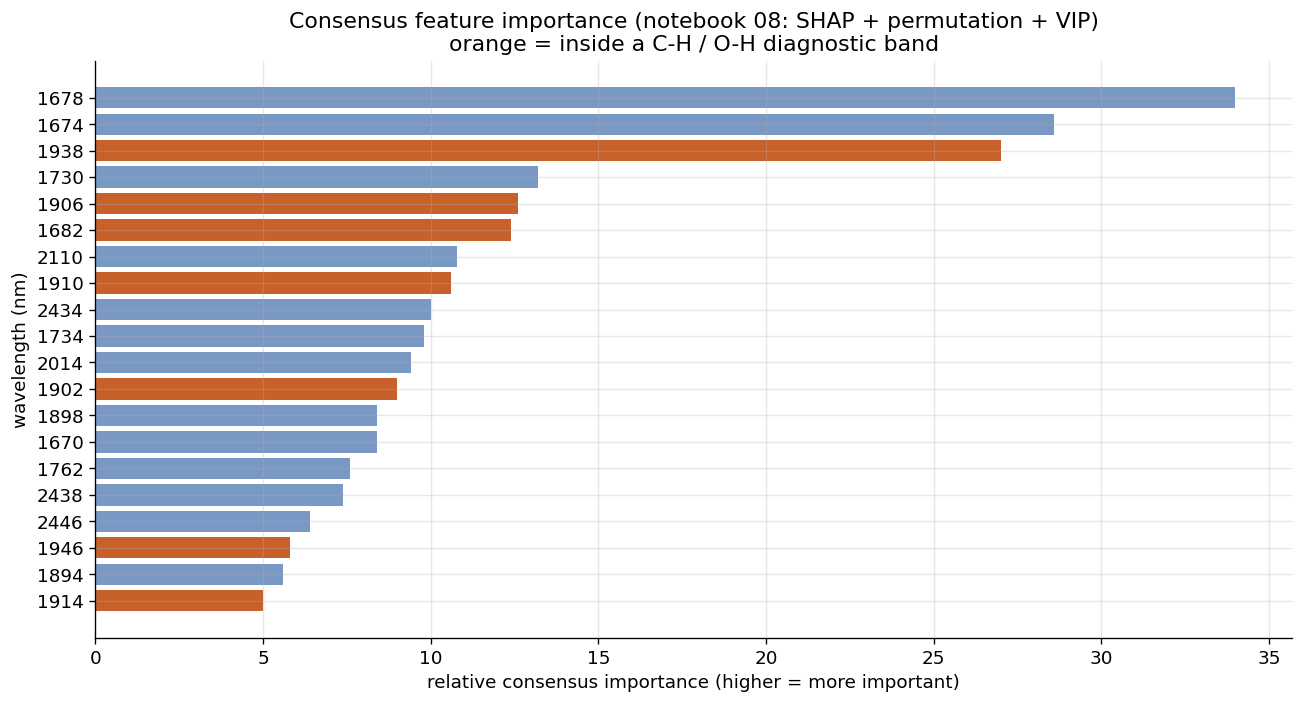

7/20 of the consensus top wavelengths fall inside a labelled diagnostic band
Dominant regions: 1670-1740 nm (C-H 1st overtone) and 1894-1946 nm (O-H).


In [6]:
# Notebook 08's rank-aggregated consensus (SHAP + permutation + VIP), lower score = more important
nb08_consensus = pd.DataFrame({
    'nm':[1678,1674,1938,1730,1906,1682,2110,1910,2434,1734,2014,1902,1898,1670,1762,2438,2446,1946,1894,1914],
    'consensus_score':[15.8,21.2,22.8,36.6,37.2,37.4,39.0,39.2,39.8,40.0,40.4,40.8,41.4,41.4,42.2,42.4,43.4,44.0,44.2,44.8],
})
nb08_consensus['band'] = nb08_consensus['nm'].map(band_of)

fig, ax = plt.subplots(figsize=(11,6))
colors = ['#c8602a' if b else '#7a98c4' for b in nb08_consensus['band']]
ax.barh(nb08_consensus['nm'].astype(str), nb08_consensus['consensus_score'].max()-nb08_consensus['consensus_score']+5,
        color=colors)
ax.set_xlabel('relative consensus importance (higher = more important)')
ax.set_ylabel('wavelength (nm)')
ax.set_title('Consensus feature importance (notebook 08: SHAP + permutation + VIP)\n'
             'orange = inside a C-H / O-H diagnostic band')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('summary_consensus_importance.png', bbox_inches='tight')
plt.show()

inband = nb08_consensus['band'].astype(bool).sum()
print(f"{inband}/20 of the consensus top wavelengths fall inside a labelled diagnostic band")
print("Dominant regions: 1670-1740 nm (C-H 1st overtone) and 1894-1946 nm (O-H).")

## 3 · Best-model recommendations

| Problem | Recommended model | CV score | Notes |
|---|---|---|---|
| **Vinyl vs hardwood** | Linear SVM (or LDA / a single PC1 threshold) | **100%** | Trivially separable; unsupervised k=2 also gives ARI=1.0. No need for anything complex. |
| **9-class** | **SVM (RBF)** or KNN (Manhattan, k=2) | **97.8%** | Tie at the top; both beat RF (97.0%), LDA (96.3%) and XGBoost (93.3%). |
| **Wood species (6)** | SVM (RBF), with KNN as robust backup | 100%* / 97.8% | *SVM hits 100% but n=44 — report KNN 97.8% as the trustworthy number. |
| **Wear-layer thickness** | **SVR (RBF)** | R²=0.974, RMSE=1.04 mil | Beats PLS (0.963 / 1.26 mil); use PLS if interpretability/VIP is required. |
| **Cheap sensor design** | RandomForest on RFE-selected wavelengths | 98.5% with ~9 wl | ~9 of 249 channels retain full accuracy → few-channel instrument is feasible. |

**XGBoost underperforms everywhere** — gradient boosting needs more rows than 134 highly-collinear spectra provide.
On this dataset, simple linear/instance-based methods (SVM, KNN, LDA) win.

## 4 · Key scientific insights

1. **Vinyl vs hardwood is an essentially solved problem.** Supervised models hit 100%, and *unsupervised*
   k=2 clustering recovers the split perfectly (ARI = 1.0), echoing the PCA PC1 (93.3% variance). The two
   material families are spectrally distinct.

2. **A handful of wavelengths carries the signal.** RFE keeps ~9 of 249 wavelengths at 98.5% 9-class accuracy
   (vs 97.0% full spectrum). The remaining ~240 channels are redundant — a low-cost few-channel NIR sensor
   would work.

3. **The important wavelengths are chemically sensible.** Across XGBoost gain, SHAP/permutation consensus,
   and ANOVA F-statistics, the C-H first-overtone (≈1690–1710 nm), O-H (≈1900–1950 nm) and C-H combination
   (≈2240–2270 nm) bands recur. ANOVA's top wood-species wavelength is 2242 nm (C-H comb.); its top 9-class
   wavelength is 1910 nm (O-H). The models are leaning on real chemistry, not artefacts.

4. **Almost every wavelength is statistically discriminating, but not equally useful.** ANOVA finds
   232/249 wavelengths significant for vinyl-vs-HW and 249/249 for the 9-class problem (Bonferroni-corrected) —
   yet RFE shows ~9 suffice. Significance ≠ non-redundancy.

5. **Wear-layer thickness is predictable to ≈1 mil.** SVR-RBF reaches R²=0.974 / RMSE=1.04 mil with
   near-zero bias, slightly better than the PLS baseline — adequate for tier assignment (6/12/22 mil).

6. **Model-family choice matters more than tuning here.** With 134 collinear samples, linear and
   instance-based methods (SVM, KNN, LDA) consistently beat the tree ensemble (XGBoost), which lagged by
   3–9 points on every classification task.

---
### Artifacts
- `summary_consensus_importance.png` — consensus feature-importance bar chart (this notebook)
- Per-analysis notebooks & figures: `01_svm_classification/` … `08_model_interpretability/`

*Final deliverable for `ANALYSIS_PLAN.md`. Generated from the executed outputs of notebooks 01–08.*